In [9]:
import os
import json
import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
from typing import Tuple

#from geocat.viz import cmaps
from hov_function import define_region, plot_multi_model_hovmoller_from_files


In [10]:
class HovmollerTimeSeries:
    def __init__(self, regnam, year, frequency,
                 model_list, ref_dict, exp_dict, path_in, out_path,
                 var_list=None, force=False, calendar="noleap",
                 hovmoller_axis="lon"):
        self.regnam = regnam
        self.frequency = frequency
        self.model_list = model_list
        self.ref_dict = ref_dict
        self.exp_dict = exp_dict
        self.path_template = path_in
        self.out_root = os.path.join(out_path, frequency)
        self.force = force
        self.calendar = calendar
        self.year = year
        self.hovmoller_axis = hovmoller_axis

        if hovmoller_axis not in ["lat", "lon"]:
            raise ValueError("`hovmoller_axis` must be 'lat' or 'lon'")

        self.years = sorted({year, year - 1})

        self.var_dict = self.extract_var_list()
        self.var_list = var_list if var_list is not None else list(self.var_dict.keys())

        self.seasons = {
            "DJF": [12, 1, 2],
            "MAM": [3, 4, 5],
            "JJA": [6, 7, 8],
            "SON": [9, 10, 11],
            "ANN": list(range(1, 13))
        }

        os.makedirs(self.out_root, exist_ok=True)

    @staticmethod
    def extract_var_list():
        return {
            "PRECT": {"alias": "PRECT", "unit": "mm day$^{-1}$", "fscl": 8.64e7}
        }

    @staticmethod
    def define_region(regnam='global'):
        reg_dict= {
            'global': [(-90, 90), (0, 360)],
            'NHMidLat': [(25, 50), (150, 300)],
            'Tropics': [(-10, 10), (60, 270)],
            'NPacific': [(10, 65), (110, 260)]
        }
        if regnam not in reg_dict:
            raise ValueError(f"Region '{regnam}' not defined.")
        return reg_dict[regnam]

    def _get_valid_months(self):
        valid_months = set()
        for season in self.seasons:
            valid_months.update(self.seasons[season])
        return valid_months

    def read_reference_data(self, var_key, ref_cfg, region_bounds):
        ref_var = ref_cfg["alias"]
        ref_fac = ref_cfg["fscl"]
        ref_dir = ref_cfg["run"]
        ref_template = ref_cfg.get("template", f"{ref_cfg['source']}_analysis_%(year).nc")
    
        lat_bounds, lon_bounds = region_bounds
        axis_to_avg = "lat" if self.hovmoller_axis == "lon" else "lon"
    
        ref_list = []
        for year in self.years:
            ref_file = os.path.join(ref_dir, ref_template.replace("%(year)", str(year)))
            if not os.path.exists(ref_file):
                continue
            try:
                ds = xr.open_dataset(ref_file)
    
                # Convert lon from [-180, 180] to [0, 360] if needed
                if (ds.lon < 0).any():
                    ds = ds.assign_coords(lon=(ds.lon % 360)).sortby('lon')
    
                ref = ds[ref_var] * ref_fac
                ref = ref.rolling(time=2).mean().shift(time=-1).isel(time=slice(1, None, 2))
                ref["time"] = ref.time - pd.Timedelta(hours=3)
                ref = ref.sel(lat=slice(*lat_bounds), lon=slice(*lon_bounds))
    
                if axis_to_avg == "lat":
                    weights = np.cos(np.deg2rad(ref.lat))
                    weights /= weights.mean()
                    ref = ref.weighted(weights).mean(dim="lat")
                else:
                    ref = ref.mean(dim="lon")
    
                ref_list.append(ref)
    
            except Exception as e:
                print(f"[ERROR] Reference {year}: {e}")
                continue
    
        if not ref_list:
            raise ValueError("[ERROR] No reference data loaded.")
    
        ref_all = xr.concat(ref_list, dim="time")
        ref_all["time"] = pd.date_range(f"{self.years[0]}-01-01", periods=ref_all.sizes["time"], freq="6h")
    
        valid_months = self._get_valid_months()
        ref_all = ref_all.sel(
            time=ref_all.time.where(
                (((ref_all.time.dt.year == self.year - 1) & (ref_all.time.dt.month == 12)) |
                 ((ref_all.time.dt.year == self.year) & (ref_all.time.dt.month != 12)))
            ).dropna("time")
        )
    
        return ref_all


    def read_model_data(self, var_key, model_cfg, varin, vfac, region_bounds, ref_time):
        lat_bounds, lon_bounds = region_bounds
        axis_to_avg = "lat" if self.hovmoller_axis == "lon" else "lon"
        valid_months = self._get_valid_months()
    
        mod_list = []
        for year in self.years:
            mod_file = os.path.join(model_cfg["run"], f"{var_key}_{year}_h1.nc")
            if not os.path.exists(mod_file):
                continue
            try:
                ds = xr.open_dataset(mod_file)
    
                # Convert lon from [-180, 180] to [0, 360] if needed
                if (ds.lon < 0).any():
                    ds = ds.assign_coords(lon=(ds.lon % 360)).sortby("lon")
    
                mod = ds[varin] * vfac
                mod = mod.sel(lat=slice(*lat_bounds), lon=slice(*lon_bounds))
    
                if axis_to_avg == "lat":
                    weights = np.cos(np.deg2rad(mod.lat))
                    weights /= weights.mean()
                    mod = mod.weighted(weights).mean(dim="lat")
                else:
                    mod = mod.mean(dim="lon")
    
                mod_list.append(mod)
    
            except Exception as e:
                print(f"[ERROR] Model {model_cfg['name']}, {year}: {e}")
                continue
    
        if not mod_list:
            return None
    
        mod_all = xr.concat(mod_list, dim="time")
        mod_all["time"] = pd.date_range(f"{self.years[0]}-01-01", periods=mod_all.sizes["time"], freq="6h")
    
        mod_all = mod_all.sel(
            time=mod_all.time.where(
                (((mod_all.time.dt.year == self.year - 1) & (mod_all.time.dt.month == 12)) |
                 ((mod_all.time.dt.year == self.year) & (mod_all.time.dt.month != 12)))
            ).dropna("time")
        )
    
        mod_all = mod_all.sel(time=ref_time)
        if not mod_all.time.equals(ref_time):
            raise ValueError(f"[ERROR] Time mismatch for model {model_cfg['name']} after alignment.")
    
        return mod_all


    def extract_hovmoller_data(self, var_key="PRECT", region=None, regnam=None, save_output=False):
        vinfo = self.var_dict[var_key]
        varin = vinfo["alias"]
        vfac = vinfo["fscl"]
        ref_cfg = self.ref_dict[var_key]

        if region is None and regnam is not None:
            region_bounds = self.define_region(regnam)
        else:
            raise ValueError("Must provide either region or regnam")

        ref_all = self.read_reference_data(var_key, ref_cfg, region_bounds)

        results = {}
        for model_name in self.model_list:
            model_cfg = {
                "name": model_name,
                "run": self.path_template.replace("%(CASENAME)", self.exp_dict[model_name]["run"])
            }
            mod_all = self.read_model_data(var_key, model_cfg, varin, vfac, region_bounds, ref_all.time)
            if mod_all is None:
                print(f"[WARNING] No model data for {model_name}")
                continue

            results[model_name] = {
                "model": mod_all.assign_attrs(units=vinfo["unit"]),
                "reference": ref_all.copy(deep=True)
            }

        if save_output:
            self.save_hovmoller_to_netcdf(results, var_key, regnam, ref_cfg, self.year)

        return results

    def save_hovmoller_to_netcdf(self, hov_dict, var_key, regnam, ref_cfg, process_year):
        axis_suffix = f"time-{self.hovmoller_axis}"
        ref_sample = next(iter(hov_dict.values()))
        ref_out_file = os.path.join(
            self.out_root,
            f"hovmoller_{ref_cfg['source']}_{regnam}_{var_key}_{process_year}_{axis_suffix}.nc"
        )
        
        if not os.path.exists(ref_out_file):
            reference = ref_sample["reference"]
            
            for dim in reference.dims:
                coord_dtype = reference.coords[dim].dtype
                if coord_dtype.kind in {"O", "S", "U"}:
                    print(f"[WARNING] Dropping incompatible coordinate: {dim}")
                    reference = reference.drop_vars(dim)

            encoding = {
                "reference": {"dtype": "float32"},
                "time": {
                    "units": "hours since 2000-01-01",
                    "calendar": self.calendar
                }
            }
            ref_ds = xr.Dataset({"reference": reference.astype("float32")})
            ref_ds.to_netcdf(ref_out_file, encoding=encoding)
            print(f"[SAVED] Reference: {ref_out_file}")
        else:
            print(f"[SKIPPED] Reference already exists: {ref_out_file}")

        for model_name, data in hov_dict.items():
            out_file = os.path.join(
                self.out_root,
                f"hovmoller_{model_name}_{regnam}_{var_key}_{process_year}_{axis_suffix}.nc"
            )
            encoding = {
                "model": {"dtype": "float32"},
                "time": {
                    "units": "hours since 2000-01-01",
                    "calendar": self.calendar
                }
            }
            if os.path.exists(out_file):
                os.remove(out_file)
            ds_out = xr.Dataset({"model": data["model"].astype("float32")})
            ds_out.to_netcdf(out_file, encoding=encoding)
            print(f"[SAVED] Model: {model_name} → {out_file}")
            
    def calculate_season_metric(self, var_key, regnam, ref_cfg, process_year, save_output=True):
        axis_suffix = f"time-{self.hovmoller_axis}"
        ref_file = os.path.join(
            self.out_root,
            f"hovmoller_{ref_cfg['source']}_{regnam}_{var_key}_{process_year}_{axis_suffix}.nc"
        )
        if not os.path.exists(ref_file):
            raise FileNotFoundError(f"[ERROR] Reference file not found: {ref_file}")
        ref_ds = xr.open_dataset(ref_file)
        ref_all = ref_ds["reference"]

        vinfo = self.var_dict[var_key]
        models = []
        seasons = list(self.seasons.keys())
        rmse_data = []
        corr_data = []

        for model_name in self.model_list:
            mod_file = os.path.join(
                self.out_root,
                f"hovmoller_{model_name}_{regnam}_{var_key}_{process_year}_{axis_suffix}.nc"
            )
            if not os.path.exists(mod_file):
                print(f"[WARNING] Missing model file: {mod_file}")
                continue
            mod_ds = xr.open_dataset(mod_file)
            mod_all = mod_ds["model"]

            model_rmses = []
            model_corrs = []

            for season_name in seasons:
                season_months = self.seasons[season_name]
                season_mask = mod_all.time.dt.month.isin(season_months)
                model_season = mod_all.sel(time=season_mask)
                ref_season = ref_all.sel(time=season_mask)
                model_season, ref_season = xr.align(model_season, ref_season)

                if model_season.sizes["time"] == 0:
                    print(f"[WARNING] No data for {model_name} in {season_name}")
                    model_rmses.append(np.nan)
                    model_corrs.append(np.nan)
                    continue

                try:
                    weights = np.cos(np.deg2rad(model_season[self.hovmoller_axis]))
                    weights /= weights.mean()
                    rmse = np.sqrt(((model_season - ref_season) ** 2).weighted(weights).mean(dim=self.hovmoller_axis)).mean(dim="time")
                    model_anom = model_season - model_season.weighted(weights).mean(dim=self.hovmoller_axis)
                    ref_anom = ref_season - ref_season.weighted(weights).mean(dim=self.hovmoller_axis)
                    numerator = (model_anom * ref_anom).weighted(weights).mean(dim=self.hovmoller_axis)
                    denominator = model_anom.weighted(weights).std(dim=self.hovmoller_axis) * ref_anom.weighted(weights).std(dim=self.hovmoller_axis)
                    corr = (numerator / denominator).mean(dim="time")
                    model_rmses.append(rmse.values.item())
                    model_corrs.append(corr.values.item())
                except Exception as e:
                    print(f"[ERROR] Metric calculation failed for {model_name} in {season_name}: {e}")
                    model_rmses.append(np.nan)
                    model_corrs.append(np.nan)

            models.append(model_name)
            rmse_data.append(model_rmses)
            corr_data.append(model_corrs)

        rmse_array = np.atleast_2d(np.array(rmse_data))
        corr_array = np.atleast_2d(np.array(corr_data))

        ds_out = xr.Dataset({
            "pattern_rmse": (("model", "season"), rmse_array),
            "pattern_corr": (("model", "season"), corr_array)
        }, coords={
            "model": models,
            "season": seasons
        })

        out_file = os.path.join(
            self.out_root,
            f"seasonal_metrics_{var_key}_{regnam}_{process_year}_{axis_suffix}.nc"
        )
        if save_output:
            if os.path.exists(out_file):
                os.remove(out_file)
            ds_out.to_netcdf(out_file)
            print(f"[SAVED] Seasonal metrics: {out_file}")
        else:
            print(f"[INFO] Computed seasonal metrics but did not save.")

        return ds_out
        

[SAVED] ./Figure_05.pdf


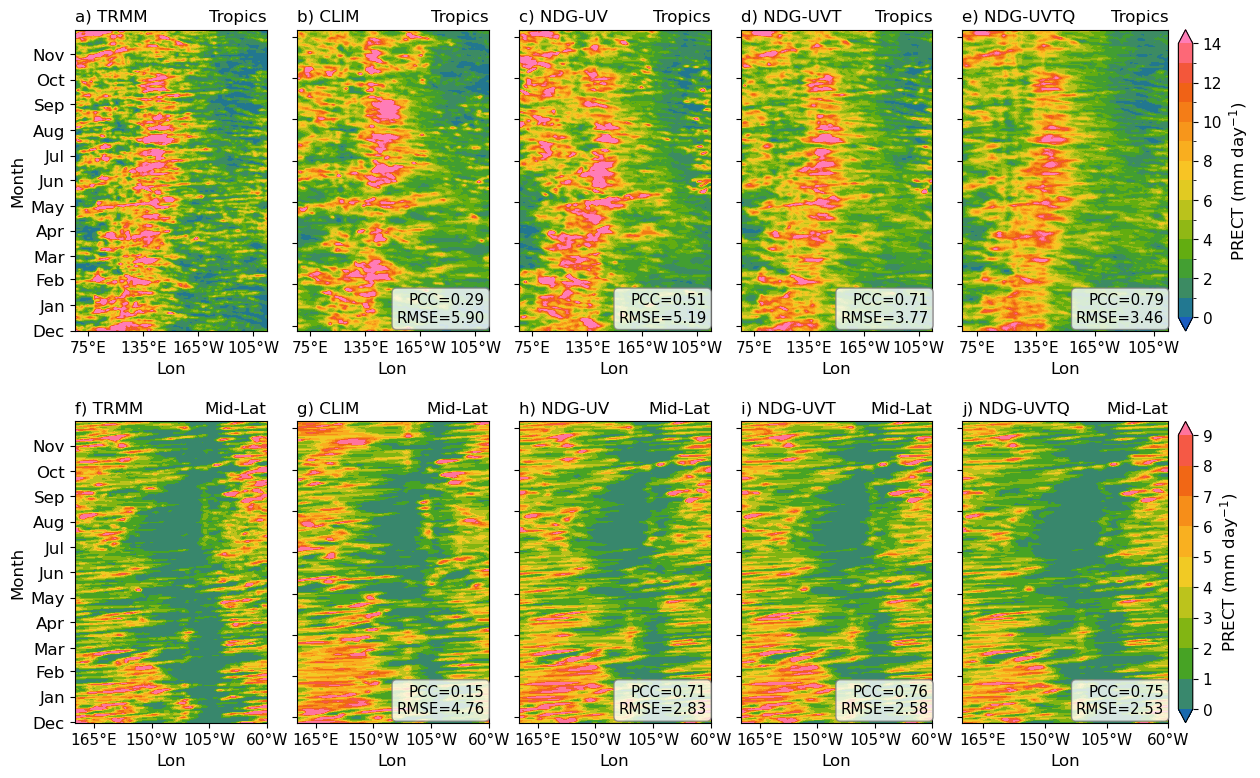

In [13]:
if __name__ == "__main__":
    # === Configuration ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data"
    out_path = "/home/x-szhang3/nudging_analysis/nudging_evaluation/data/hovmoller_output"
    os.makedirs(out_path, exist_ok=True)
    fig_path = "./"
    os.makedirs(fig_path, exist_ok=True)
    
    process_year = 2011
    varname = "PRECT"
    frequency = "6hourly"
    hovmoller_axis = "lon"  # change to "lat" for time–latitude plots
    regnams = ["Tropics", "NHMidLat"] #  ['NHMidLat','NPacific','Tropics']
    process_plot_data = False # if plot data not exist, process it 
    
    model_dict = {
                  "TRMM"   : "TRMM", 
                  "CLIM"   : "CLIM", 
                  "NDGUV"  : "NDG-UV", 
                  "NDGUVT" : "NDG-UVT", 
                  "NDGUVTQ": "NDG-UVTQ"
                 }
    model_to_varname = {"TRMM": "reference"}
    
    if process_plot_data: 
        exp_json = "/home/x-szhang3/nudging_analysis/nudge_exp_info.json"
        with open(exp_json, "r") as f:
            exp_dict = json.load(f)
    
        ref_dict = {
            "PRECT": {
                "source": "TRMM",
                "alias": "PRECT",
                "fscl": 24.0,  # mm/hr → mm/day
                "run": f"{data_path}/OBS/TRMM/3hourly",
                "template": "TRMM_3hourly_%(year)_1x1.nc",
                #"template": "TRMM_3B42_3hourly_%(year)_1x1.nc",
                "period": "200901-201112"
            }
        }
        print(f"\n[INFO] Processing year {process_year} for {hovmoller_axis.upper()} Hovmöller")
        
        for region_name in regnams:
            hts = HovmollerTimeSeries(
                regnam=region_name,
                year=process_year,
                frequency=frequency,
                model_list=list(exp_dict.keys()),
                ref_dict=ref_dict,
                exp_dict=exp_dict,
                path_in=f"{data_path}/%(CASENAME)/{frequency}",
                out_path=out_path,
                var_list=None,
                force=False,
                calendar="noleap",
                hovmoller_axis=hovmoller_axis
            )
    
            hts.extract_hovmoller_data(
                var_key=varname,
                regnam=region_name,
                save_output=True
            )
        
            hts.calculate_season_metric(
                var_key=varname,
                regnam=region_name,
                ref_cfg=ref_dict[varname],
                process_year=process_year,
                save_output=True
            )

    # do plot #
    fig_name = "Figure_05.pdf"
    reg_dict = {"Tropics" : {
                        'reg_str': 'Tropics',
                        'clevels': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14], 
                        'region' : define_region("Tropics"),
                        'xticks' : [75, 135, 195, 255]

                    },
                "NHMidLat": {
                        'reg_str': 'Mid-Lat',
                        #'clevels': [0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10],
                        'clevels': [0,1,2,3,4,5,6,7,8,9],
                        'region' : define_region("NHMidLat"),
                        'xticks' : [165, 210, 255, 300]
                    }
                }

    # === Colormap and Color Levels ===
    base_cmap = cc.cm["CET_R1"]
    
    # Normalize longitudes in region bounds and xticks if plotting over longitude
    if hovmoller_axis == "lon":
        for reg in reg_dict.values():
            lat_bounds, lon_bounds = reg['region']
            reg['region'] = (lat_bounds, [lon % 360 for lon in lon_bounds])
            reg['xticks'] = [xt % 360 for xt in reg['xticks']]
            
    # === Call Revised Function ===
    plot_multi_model_hovmoller_from_files(
        data_dir=os.path.join(out_path, frequency),
        model_dict=model_dict,
        varname=varname,
        model_to_varname=model_to_varname,
        reg_dict=reg_dict,
        process_year=process_year,
        hovmoller_axis=hovmoller_axis,
        base_cmap=base_cmap,
        panel_width=2.5,           # Width per subplot
        panel_height=4.5,          # Height per subplot
        resample_to_daily=True,
        reverse_x=True,
        reverse_y=False,
        save_path=fig_path,
        show_plot=True,
        fig_name=fig_name
    )